## Read the Dataset

In [1]:
import pandas as pd

In [3]:
chd_df = pd.read_csv("/content/SAheart.csv")

In [4]:
chd_df.head(10)

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
5,6,132,6.20,6.47,36.21,Present,62,30.77,14.14,45,0
6,7,142,4.05,3.38,16.20,Absent,59,20.81,2.62,38,0
7,8,114,4.08,4.59,14.60,Present,62,23.11,6.72,58,1
8,9,114,0.00,3.83,19.40,Present,49,24.86,2.49,29,0
9,10,132,0.00,5.80,30.96,Present,69,30.11,0.00,53,1


In [23]:
chd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   row.names   462 non-null    int64  
 1   sbp         462 non-null    int64  
 2   tobacco     462 non-null    float64
 3   ldl         462 non-null    float64
 4   adiposity   462 non-null    float64
 5   famhist     462 non-null    object 
 6   typea       462 non-null    int64  
 7   obesity     462 non-null    float64
 8   alcohol     462 non-null    float64
 9   age         462 non-null    int64  
 10  chd         462 non-null    int64  
 11  famhist_en  462 non-null    int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 43.4+ KB


In [5]:
chd_df['famhist_en'] = chd_df['famhist'].map(lambda x: 1 if x == 'Present' else 0)

In [7]:
chd_df.head(5)

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd,famhist_en
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1,0
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0,1
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1,1


## Set X and y

In [8]:
chd_df.columns

Index(['row.names', 'sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea',
       'obesity', 'alcohol', 'age', 'chd', 'famhist_en'],
      dtype='object')

In [9]:
x_features = list(chd_df.columns)

In [10]:
x_features

['row.names',
 'sbp',
 'tobacco',
 'ldl',
 'adiposity',
 'famhist',
 'typea',
 'obesity',
 'alcohol',
 'age',
 'chd',
 'famhist_en']

In [13]:
x_features.remove('row.names')
x_features.remove('famhist')
x_features.remove('chd')

In [14]:
x_features

['sbp',
 'tobacco',
 'ldl',
 'adiposity',
 'typea',
 'obesity',
 'alcohol',
 'age',
 'famhist_en']

In [15]:
X = chd_df[x_features]
y = chd_df.chd

## Split the dataset

In [19]:
from sklearn.model_selection import train_test_split

In [25]:
train_X, test_X, train_y, test_y = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 100)

In [26]:
train_X.shape

(369, 9)

In [28]:
train_X[0:10]

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_en
1,144,0.01,4.41,28.61,55,28.87,2.06,63,0
310,174,3.50,5.26,21.97,36,22.04,8.33,59,1
430,118,0.00,3.89,15.96,65,20.18,0.00,16,0
21,132,7.90,2.85,26.50,51,26.16,25.71,44,1
271,136,2.20,4.16,38.02,65,37.24,4.11,41,0
19,124,14.00,6.23,35.96,45,30.09,0.00,59,1
392,178,0.95,4.75,21.06,49,23.74,24.69,61,0
37,110,4.64,4.55,30.46,48,30.90,15.22,46,0
160,126,1.80,6.22,19.71,65,24.81,0.69,31,0
337,138,6.00,7.24,37.05,38,28.69,0.00,59,0


In [27]:
test_X.shape

(93, 9)

## Normalization

In [29]:
mean = train_X.mean()
std = train_X.std()

In [30]:
train_X = (train_X - mean)/std

In [31]:
test_X = (test_X - mean)/std

## Build the model

In [33]:
import keras

In [35]:
keras.__version__

'3.13.2'

In [39]:
from keras.layers import Dense, Activation

In [92]:
model = keras.Sequential()

model.add(Dense(64, input_shape=(train_X.shape[1],)))
model.add(Activation("relu"))

model.add(Dense(1))
model.add(Activation("sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
from keras.optimizers import SGD, Adam

In [102]:
sgd = Adam(learning_rate=0.01)

In [103]:
model.compile(optimizer=sgd,
             loss="binary_crossentropy",
             metrics=["accuracy"])

In [104]:
EPOCHS = 30
batch_size = 64

In [105]:
model.fit(train_X,
          train_y,
          epochs=EPOCHS,
          batch_size=batch_size,
          validation_data = (test_X, test_y))

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7073 - loss: 0.5434 - val_accuracy: 0.6989 - val_loss: 0.6180
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7507 - loss: 0.4966 - val_accuracy: 0.6882 - val_loss: 0.6147
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7507 - loss: 0.4803 - val_accuracy: 0.6559 - val_loss: 0.6245
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7561 - loss: 0.4681 - val_accuracy: 0.6559 - val_loss: 0.6350
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7642 - loss: 0.4614 - val_accuracy: 0.6559 - val_loss: 0.6377
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7832 - loss: 0.4543 - val_accuracy: 0.6667 - val_loss: 0.6381
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8076 - loss: 0.4466 - val_accuracy: 0.6667 - val_loss: 0.6294
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7913 - loss: 0.4389 - val_accuracy: 0.6559 - val_loss: 0.6364


## Exercises

1. Change model architecture
2. Add callbacks - Reduce LR, Early stopping, save best models

## Validation

In [113]:
y_pred_probs = model.predict(test_X)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [126]:
pred_y = (y_pred_probs > 0.5).astype(int).ravel()

In [127]:
pred_y

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1])

In [121]:
from sklearn.metrics import confusion_matrix

In [134]:
cm = confusion_matrix(test_y, pred_y, labels= [1,0])

In [135]:
cm

array([[19, 19],
       [13, 42]])

In [136]:
from sklearn.metrics import ConfusionMatrixDisplay

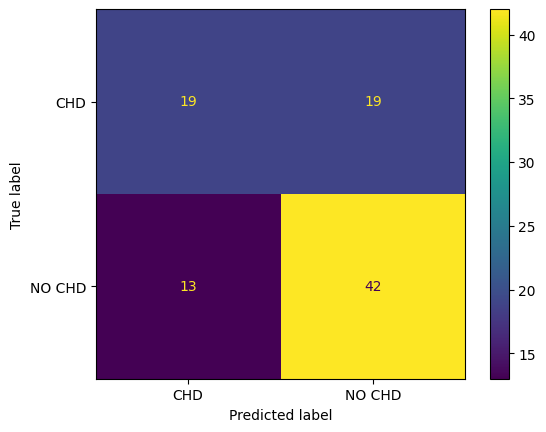

In [138]:
ConfusionMatrixDisplay(cm, display_labels=['CHD', 'NO CHD']).plot();